In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor

In [5]:
df = pd.read_csv("train.csv")
df = df.drop("id",axis=1)
df.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [7]:
df.isnull().sum()

age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

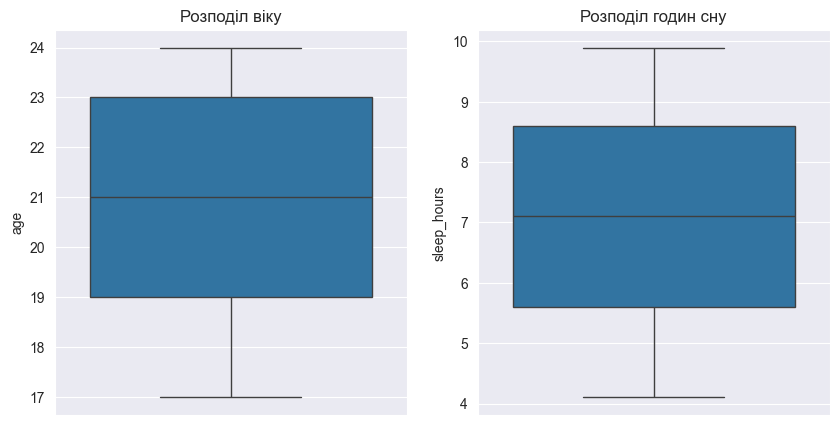

In [15]:
fig, axes = plt.subplots(1,2,figsize=(10,5))

sns.boxplot(data=df, y='age', ax=axes[0])
axes[0].set_title('Розподіл віку')

sns.boxplot(data=df, y='sleep_hours', ax=axes[1])
axes[1].set_title('Розподіл годин сну')

plt.show()

In [16]:
df['gender'].value_counts()

gender
other     211097
male      210593
female    208310
Name: count, dtype: int64

In [24]:
statistic_gender_and_exam = pd.DataFrame(df.groupby(['gender','exam_difficulty'])['exam_score'].mean())
statistic_gender_and_exam

exam_score
gender exam_difficulty            
female easy              62.268493
       hard              62.715400
       moderate          62.665295
male   easy              61.967015
       hard              62.353600
       moderate          62.231707
other  easy              62.411947
       hard              62.937087
       moderate          62.920979

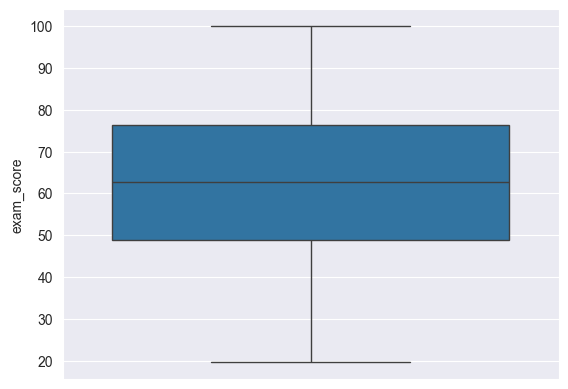

In [27]:
sns.boxplot(df["exam_score"])
plt.show()

In [21]:
df['exam_difficulty'].value_counts()

exam_difficulty
moderate    353982
easy        176540
hard         99478
Name: count, dtype: int64

In [28]:
df.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [32]:
categories = ['gender','course','internet_access','sleep_quality','study_method','facility_rating','exam_difficulty']
X = df.drop("exam_score",axis=1)
y = df["exam_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
cb_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=5,
    l2_leaf_reg=3,
    loss_function='RMSE',
    od_type='Iter',
    od_wait=50,
    random_seed=42,
    verbose=False,
)

cb_model.fit(X_train, y_train,cat_features=categories,eval_set=(X_test,y_test))
y_pred = cb_model.predict(X_test)

In [36]:
from sklearn.metrics import r2_score

In [54]:
r2_score(y_test,y_pred)

0.7829308984478737

In [45]:
df.head(1)

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3


In [44]:
df.columns

Index(['age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

<Axes: >

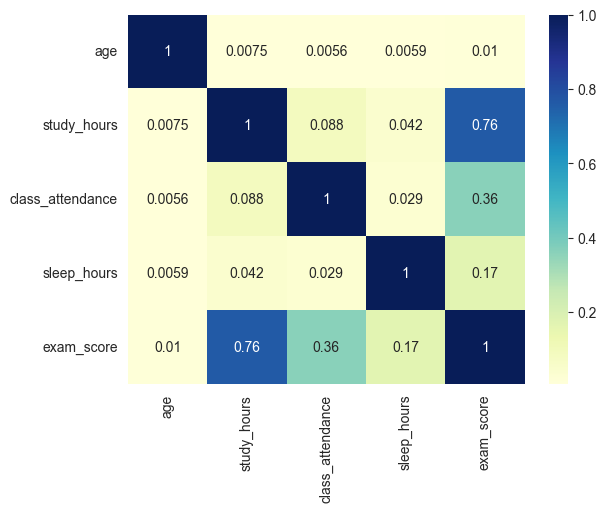

In [46]:
sns.heatmap(df[['age','study_hours','class_attendance','sleep_hours','exam_score']].corr(), annot=True, cmap="YlGnBu")

<Axes: ylabel='exam_score'>

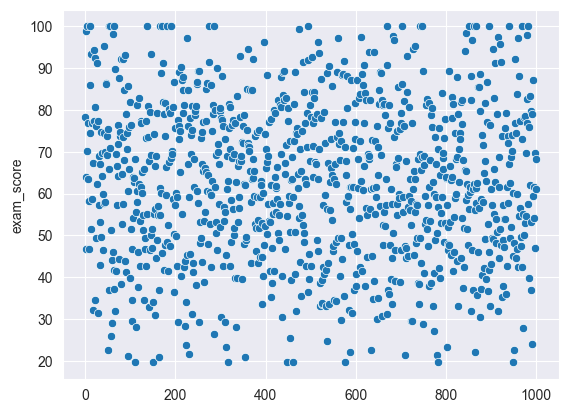

In [42]:
sns.scatterplot(df['exam_score'][:1000])

In [58]:
df_test = pd.read_csv("test.csv")
X_final_test = df_test.drop("id",axis=1)

In [59]:
y_final_test = cb_model.predict(X_final_test)

In [63]:
submission = pd.DataFrame({
    "id": df_test["id"],
    "exam_score": y_final_test
})

submission.to_csv("submission.csv", index=False)